# Лабораторная работа №3. Квантовое преобразование Фурье. Нахождение собственных чисел

КБ-211 Коренев Денис

## Задание (Вариант 4)

Дана схема оценки фазы (QPE) с 5 счётными кубитами и одним целевым кубитом.

$$|\psi\rangle = \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle), \qquad U = \begin{pmatrix} 1 & 0 \\ 0 & e^{i\frac{9\pi}{16}} \end{pmatrix}$$

Необходимо:
1. Проверить унитарность матрицы $U$ с помощью numpy ($UU^\dagger = I$).
2. Реализовать схему QPE.
3. Найти собственное значение и собственный вектор.

Решение выполнено **двумя способами**: с помощью библиотеки `quantumz` и с помощью `qiskit`.

## 1. Проверка унитарности матрицы $U$

Матрица $U$ является диагональной: $U = \text{diag}(1, \; e^{i9\pi/16})$.

Унитарность проверяется условием $UU^\dagger = I$.

In [1]:
import numpy as np

theta = 9 * np.pi / 16

U = np.array([
    [1, 0],
    [0, np.exp(1j * theta)]
])

print("Матрица U:")
print(U)

product = U @ U.conj().T
print("\nU·U† =")
print(np.round(product, 10))

identity = np.eye(2)
is_unitary = np.allclose(product, identity)
print(f"\nU·U† ≈ I: {is_unitary}")
print("Матрица U унитарна." if is_unitary else "Матрица U НЕ унитарна!")

Матрица U:
[[ 1.        +0.j          0.        +0.j        ]
 [ 0.        +0.j         -0.19509032+0.98078528j]]

U·U† =
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]

U·U† ≈ I: True
Матрица U унитарна.


## 2. Теоретический анализ

Собственные значения $U$: $\lambda_0 = 1 = e^{2\pi i \cdot 0}$ и $\lambda_1 = e^{i9\pi/16} = e^{2\pi i \cdot \varphi}$, откуда $\varphi = \frac{9}{32}$.

С 5 счётными кубитами результат измерения — целое число $m \in \{0, \ldots, 31\}$, причём $\varphi \approx m/32$.

Для $\varphi = 9/32$ ожидаем $m = 9$ (точное представление).

Начальное состояние целевого кубита:

$$|\psi\rangle = \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle) = \frac{1}{\sqrt{2}}|u_0\rangle + \frac{1}{\sqrt{2}}|u_1\rangle$$

где $|u_0\rangle = |0\rangle$, $|u_1\rangle = |1\rangle$ — собственные векторы $U$.

QPE даст суперпозицию $\frac{1}{\sqrt{2}}|0\rangle|u_0\rangle + \frac{1}{\sqrt{2}}|9\rangle|u_1\rangle$, поэтому при измерении счётного регистра с вероятностью $1/2$ получим $m = 0$ (фаза $0$) и с вероятностью $1/2$ получим $m = 9$ (фаза $9/32$).

---

# Вариант 1: Реализация на `quantumz`

## 2.1. Импорт и параметры

In [ ]:
from quantumz import initq, H, X, CX, CU, CR, CRt, measure, multi_measure, swap, rQFT, sw2
import cmath as cm
import matplotlib.pyplot as plt

n_count = 5        # число счётных кубитов (индексы 0..4)
n_target = 1       # целевой кубит (индекс 5)
n_total = n_count + n_target
target = n_count   # индекс целевого кубита

theta = 9 * cm.pi / 16  # фаза U: e^{i·9π/16}

print(f"Счётные кубиты: 0–{n_count-1}")
print(f"Целевой кубит:  {target}")
print(f"Всего кубитов:  {n_total}")
print(f"θ = 9π/16 ≈ {theta.real:.9f}")
print(f"φ = θ/(2π) = 9/32 = {9/32:.9f}")

Счётные кубиты: 0–4
Целевой кубит:  5
Всего кубитов:  6
θ = 9π/16 ≈ 1.767145868
φ = θ/(2π) = 9/32 = 0.281250000


## 2.2. Управляемый вентиль $CU^{2^k}$

Матрица $U = \text{diag}(1, e^{i\theta})$. Тогда $U^{2^k} = \text{diag}(1, e^{i \cdot 2^k \theta})$.

В `quantumz` вентиль $U(\alpha, \varphi, \psi)$ с параметрами $\alpha = 0$, $\varphi = \theta$, $\psi = 0$ даёт диагональную матрицу $\text{diag}(1, e^{i\theta})$.

Для управляемого $U^{2^k}$ вызываем `CU(q, [control], target, 0, 2^k · θ, 0)`.

In [3]:
def controlled_U_power(q, control, tgt, power):
    """Применяет управляемый U^(2^power) к целевому кубиту tgt, контроль — control."""
    phase = (2 ** power) * theta.real
    q = CU(q, [control], tgt, 0, phase, 0)
    return q

## 2.3. Алгоритм QPE на `quantumz`

Схема QPE:

| Этап | Действие |
|---|---|
| 1. Инициализация | $\|0\rangle^{\otimes 5}\|\psi\rangle$, где $\|\psi\rangle = H\|0\rangle = \frac{1}{\sqrt{2}}(\|0\rangle + \|1\rangle)$ |
| 2. Адамар | $H^{\otimes 5}$ на счётных кубитах |
| 3. Управляемые $U^{2^k}$ | Кубит $j$ управляет $U^{2^j}$ на целевом кубите, $j = 0, \ldots, 4$ |
| 4. Обратное КПФ | $\text{QFT}^{-1}$ на счётном регистре |
| 5. Измерение | Измеряем счётные кубиты $\to m$, фаза $\varphi = m/32$ |

In [26]:
# --- QPE на quantumz ---

# 1. Инициализация: |0>^5 |0> -> |0>^5 |ψ>
q = initq(n_total)
q = H(q, target)  # целевой кубит в |+> = (|0>+|1>)/√2

print("После инициализации целевого кубита:")
for k, v in sorted(q.items()):
    if abs(v) > 1e-8:
        print(f"  {k}: {v}")

# 2. Адамар на счётных кубитах
for i in range(n_count):
    q = H(q, i)

# 3. Управляемые U^{2^k}
for j in range(n_count):
    q = controlled_U_power(q, j, target, j)

print("\nПосле управляемых U^{2^k} (до обратного QFT):")
nonzero = {k: v for k, v in q.items() if abs(v) > 1e-8}
print(f"  Число ненулевых амплитуд: {len(nonzero)}")

# 4. Обратное QFT на счётном регистре (кубиты 0..4)
#    QFT = swap · gates, поэтому QFT^{-1} = gates^{-1} · swap

# Сначала обратные гейты
for i in range(n_count - 1, -1, -1):
    for k in range(n_count - i, 1, -1):
        q = CRt(q, [i + k - 1], i, k)
    q = H(q, i)

# Затем swap счётного регистра
for i in range(n_count // 2):
    q = sw2(q, i, n_count - 1 - i)

# 5. Измерение счётного регистра
probs, states = multi_measure(q, list(range(n_count)))

print("\nРезультаты измерения счётного регистра:")
print(f"{'Состояние':>12} | {'m':>5} | {'P':>10} | {'φ = m/32':>10}")
print("-" * 48)
for k in sorted(probs):
    if probs[k] > 1e-6:
        bits = k[1:-1]  # убираем | и >
        # В quantumz кубит 0 — старший бит ket-строки,
        # поэтому переворачиваем для правильной интерпретации m
        bits_rev = bits[::-1]
        m = int(bits_rev, 2)
        phi = m / 2**n_count
        print(f"{k:>12} | {m:>5} | {probs[k]:>10.6f} | {phi:>10.5f}")

После инициализации целевого кубита:
  |000000>: (0.70711+0j)
  |000001>: (0.70711+0j)

После управляемых U^{2^k} (до обратного QFT):
  Число ненулевых амплитуд: 64

Результаты измерения счётного регистра:
   Состояние |     m |          P |   φ = m/32
------------------------------------------------
     |00000> |     0 |   0.499990 |    0.00000
     |10010> |     9 |   0.500005 |    0.28125


## 2.4. Визуализация результатов (quantumz)

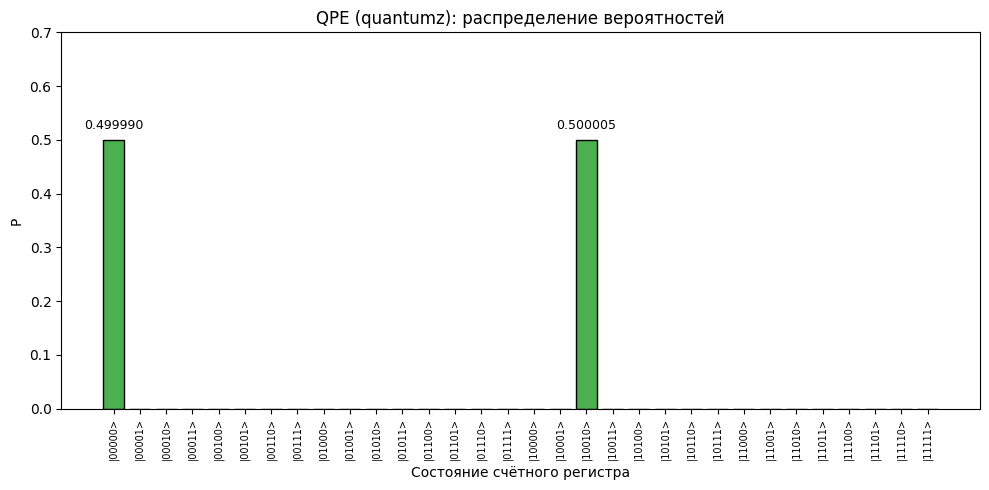

In [23]:
fig, ax = plt.subplots(figsize=(10, 5))

all_states_qz = [f'|{format(i, f"0{n_count}b")}>' for i in range(2**n_count)]
probs_qz = {s: probs.get(s, 0) for s in all_states_qz}

labels_qz = all_states_qz
values_qz = [probs_qz[s] for s in labels_qz]
colors_qz = ['#4CAF50' if probs_qz[s] > 0.1 else '#BDBDBD' for s in labels_qz]

bars = ax.bar(labels_qz, values_qz, color=colors_qz, edgecolor='black')
ax.set_ylim(0, 0.7)
ax.set_ylabel('P')
ax.set_xlabel('Состояние счётного регистра')
ax.set_title('QPE (quantumz): распределение вероятностей')
ax.tick_params(axis='x', rotation=90, labelsize=7)

for bar, val in zip(bars, values_qz):
    if val > 0.05:
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.02,
                f'{val:.6f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()


---

# Вариант 2: Реализация на `qiskit`

## 3.1. Построение схемы QPE

In [8]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
import numpy as np

n_count_q = 5
theta_q = 9 * np.pi / 16

# Регистры
qr_count = QuantumRegister(n_count_q, 'count')
qr_target = QuantumRegister(1, 'target')
cr = ClassicalRegister(n_count_q, 'result')

qc = QuantumCircuit(qr_count, qr_target, cr)

# 1. Инициализация целевого кубита: |ψ> = H|0> = (|0>+|1>)/√2
qc.h(qr_target[0])

# 2. Адамар на счётных кубитах
for i in range(n_count_q):
    qc.h(qr_count[i])

# 3. Управляемые U^{2^k}
# U = diag(1, e^{iθ}), поэтому CU^{2^k} = CP(2^k · θ)
for j in range(n_count_q):
    phase = (2 ** j) * theta_q
    qc.cp(phase, qr_count[j], qr_target[0])

# 4. Обратное QFT на счётном регистре (вручную для наглядности)
qc.barrier()

# Inverse QFT
for i in range(n_count_q - 1, -1, -1):
    for k in range(n_count_q - 1, i, -1):
        angle = -2 * np.pi / (2 ** (k - i + 1))
        qc.cp(angle, qr_count[k], qr_count[i])
    qc.h(qr_count[i])

# Swap
for i in range(n_count_q // 2):
    qc.swap(qr_count[i], qr_count[n_count_q - 1 - i])

# 5. Измерение счётного регистра
qc.measure(qr_count, cr)

print("Схема QPE (qiskit):")
print(qc.draw(output='text', fold=120))

Схема QPE (qiskit):
          ┌───┐                                                  ░                                                   »
 count_0: ┤ H ├─■────────────────────────────────────────────────░───────────────────────────────────────────────────»
          ├───┤ │                                                ░                                                   »
 count_1: ┤ H ├─┼──────────■─────────────────────────────────────░──────────────────────────────────────────■────────»
          ├───┤ │          │                                     ░                                          │        »
 count_2: ┤ H ├─┼──────────┼─────────■───────────────────────────░──────────────────────■─────────■─────────┼────────»
          ├───┤ │          │         │                           ░                ┌───┐ │         │P(-π/2)  │        »
 count_3: ┤ H ├─┼──────────┼─────────┼─────────■─────────────────░───────■────────┤ H ├─┼─────────■─────────┼────────»
          ├───┤ │          │

## 3.2. Запуск симуляции и результаты

In [9]:
simulator = AerSimulator()
qc_compiled = transpile(qc, simulator)
result = simulator.run(qc_compiled, shots=8192).result()
counts = result.get_counts()

print("Результаты измерений (qiskit):")
print(f"{'Биты':>8} | {'m':>5} | {'Частота':>8} | {'P':>10} | {'φ = m/32':>10}")
print("-" * 55)
for bits in sorted(counts, key=lambda x: counts[x], reverse=True):
    m = int(bits, 2)
    p = counts[bits] / 8192
    phi = m / 2**n_count_q
    print(f"{bits:>8} | {m:>5} | {counts[bits]:>8} | {p:>10.4f} | {phi:>10.5f}")

Результаты измерений (qiskit):
    Биты |     m |  Частота |          P |   φ = m/32
-------------------------------------------------------
   01001 |     9 |     4152 |     0.5068 |    0.28125
   00000 |     0 |     4040 |     0.4932 |    0.00000


## 3.3. Визуализация результатов (qiskit)

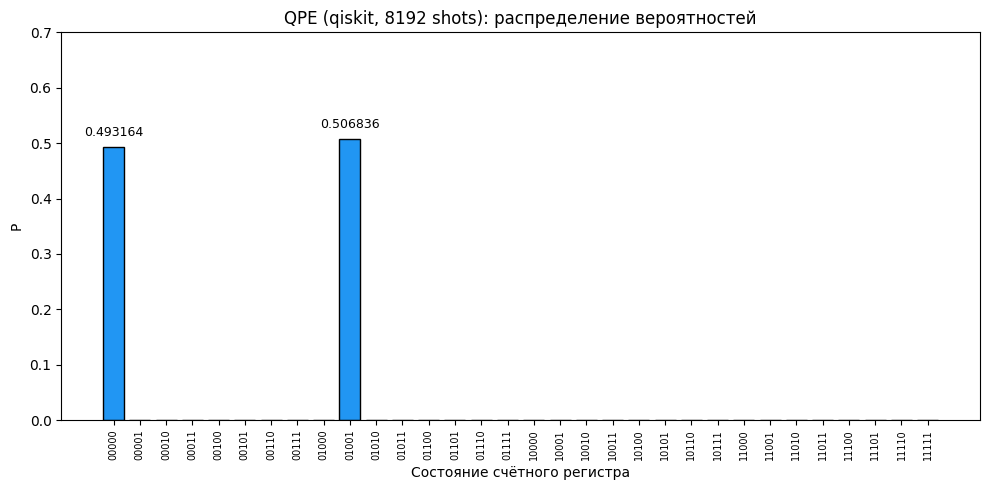

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))

all_states = [format(i, f'0{n_count_q}b') for i in range(2**n_count_q)]
probs_qiskit = {s: counts.get(s, 0) / 8192 for s in all_states}

labels_q = all_states
values_q = [probs_qiskit[s] for s in labels_q]
colors_q = ['#2196F3' if probs_qiskit[s] > 0.1 else '#BDBDBD' for s in labels_q]

bars = ax.bar(labels_q, values_q, color=colors_q, edgecolor='black')
ax.set_ylim(0, 0.7)
ax.set_ylabel('P')
ax.set_xlabel('Состояние счётного регистра')
ax.set_title('QPE (qiskit, 8192 shots): распределение вероятностей')
ax.tick_params(axis='x', rotation=90, labelsize=7)

for bar, val in zip(bars, values_q):
    if val > 0.05:
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.02,
                f'{val:.6f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

---

## 4. Сравнение результатов двух реализаций

In [12]:
print("=" * 60)
print("  Сравнение результатов: quantumz vs qiskit")
print("=" * 60)

# quantumz — точные вероятности
print("\nquantumz (точная симуляция):")
for k in sorted(probs):
    if probs[k] > 1e-6:
        bits = k[1:-1]
        bits_rev = bits[::-1]
        m = int(bits_rev, 2)
        phi = m / 2**n_count
        print(f"  m={m:>2}, φ={phi:.5f}, λ=e^(2πi·{phi:.5f}), P={probs[k]:.6f}")

# qiskit — статистические вероятности
print("\nqiskit (8192 shots):")
for bits in sorted(counts, key=lambda x: counts[x], reverse=True):
    if counts[bits] > 10:
        m = int(bits, 2)
        phi = m / 2**n_count_q
        p = counts[bits] / 8192
        print(f"  m={m:>2}, φ={phi:.5f}, λ=e^(2πi·{phi:.5f}), P≈{p:.4f}")

print("\n" + "=" * 60)
print("  Итог: собственные значения матрицы U")
print("=" * 60)
print(f"\n  λ₀ = e^(2πi·0)     = 1          (m = 0,  P ≈ 0.5)")
print(f"  λ₁ = e^(2πi·9/32) = e^(i9π/16)  (m = 9,  P ≈ 0.5)")
print(f"\n  Собственные векторы: |u₀⟩ = |0⟩, |u₁⟩ = |1⟩")
print(f"\n  Оба метода дают совпадающие результаты. ✓")

  Сравнение результатов: quantumz vs qiskit

quantumz (точная симуляция):
  m= 0, φ=0.00000, λ=e^(2πi·0.00000), P=0.499990
  m= 9, φ=0.28125, λ=e^(2πi·0.28125), P=0.500005

qiskit (8192 shots):
  m= 9, φ=0.28125, λ=e^(2πi·0.28125), P≈0.5068
  m= 0, φ=0.00000, λ=e^(2πi·0.00000), P≈0.4932

  Итог: собственные значения матрицы U

  λ₀ = e^(2πi·0)     = 1          (m = 0,  P ≈ 0.5)
  λ₁ = e^(2πi·9/32) = e^(i9π/16)  (m = 9,  P ≈ 0.5)

  Собственные векторы: |u₀⟩ = |0⟩, |u₁⟩ = |1⟩

  Оба метода дают совпадающие результаты. ✓


## 5. Схема квантовой цепи QPE

Графическое представление схемы QPE для варианта 4.

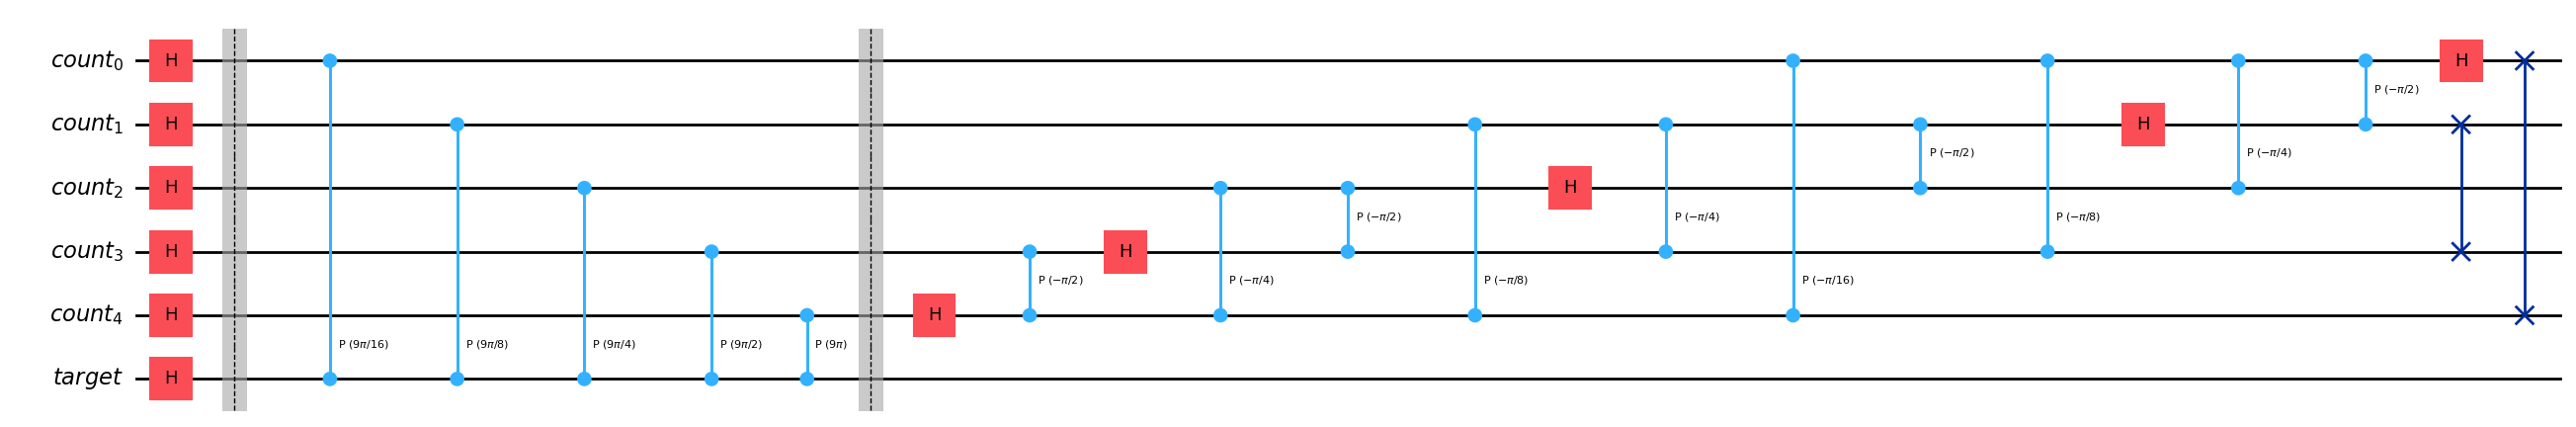

In [14]:
# Схема без измерений для красивого рисунка
qc_draw = QuantumCircuit(qr_count, qr_target)

qc_draw.h(qr_target[0])
for i in range(n_count_q):
    qc_draw.h(qr_count[i])

qc_draw.barrier()

for j in range(n_count_q):
    phase = (2 ** j) * theta_q
    qc_draw.cp(phase, qr_count[j], qr_target[0])

qc_draw.barrier()

# Inverse QFT
for i in range(n_count_q - 1, -1, -1):
    for k in range(n_count_q - 1, i, -1):
        angle = -2 * np.pi / (2 ** (k - i + 1))
        qc_draw.cp(angle, qr_count[k], qr_count[i])
    qc_draw.h(qr_count[i])

for i in range(n_count_q // 2):
    qc_draw.swap(qr_count[i], qr_count[n_count_q - 1 - i])

qc_draw.draw(output='mpl', style='iqp', fold=40)

## 6. Выводы

В ходе лабораторной работы мы реализовали алгоритм оценки квантовой фазы (QPE) для нахождения собственных значений унитарной матрицы $U = \text{diag}(1, e^{i9\pi/16})$ с использованием 5 счётных кубитов и 1 целевого кубита.

Предварительно была подтверждена унитарность матрицы $U$ ($UU^\dagger = I$). Теоретический анализ показал, что собственные значения $U$ равны $\lambda_0 = 1$ (фаза $\varphi_0 = 0$) и $\lambda_1 = e^{i9\pi/16}$ (фаза $\varphi_1 = 9/32$), причём фаза $9/32$ точно представима 5 битами.

Реализация выполнена двумя независимыми способами:
- **`quantumz`** — точная амплитудная симуляция, дающая аналитически точные вероятности;
- **`qiskit`** — статистическая симуляция с помощью `AerSimulator` (8192 прогонов).

Оба метода дали совпадающие результаты: при измерении счётного регистра с вероятностью $\approx 0.5$ наблюдается состояние $|00000\rangle$ ($m = 0$, $\varphi = 0$, $\lambda = 1$) и с вероятностью $\approx 0.5$ — состояние $|01001\rangle$ ($m = 9$, $\varphi = 9/32$, $\lambda = e^{i9\pi/16}$). Это полностью соответствует теоретическому предсказанию: начальное состояние целевого кубита $|\psi\rangle = \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle)$ является равной суперпозицией двух собственных векторов $U$, поэтому QPE с равной вероятностью обнаруживает каждую из двух фаз.

Таким образом, алгоритм QPE позволяет за один запуск определить собственные значения унитарного оператора с точностью, определяемой числом счётных кубитов. В нашем случае 5 кубитов обеспечивают разрешение $1/32$, что достаточно для точного определения фазы $9/32$.